Berhasil memuat file: data set harga phone.csv
Kolom 'price_range' tidak ada. Membuat label simulasi berdasarkan RAM...
Memulai Melatih atau Training SGD...
Latihan atau Training Selesai!


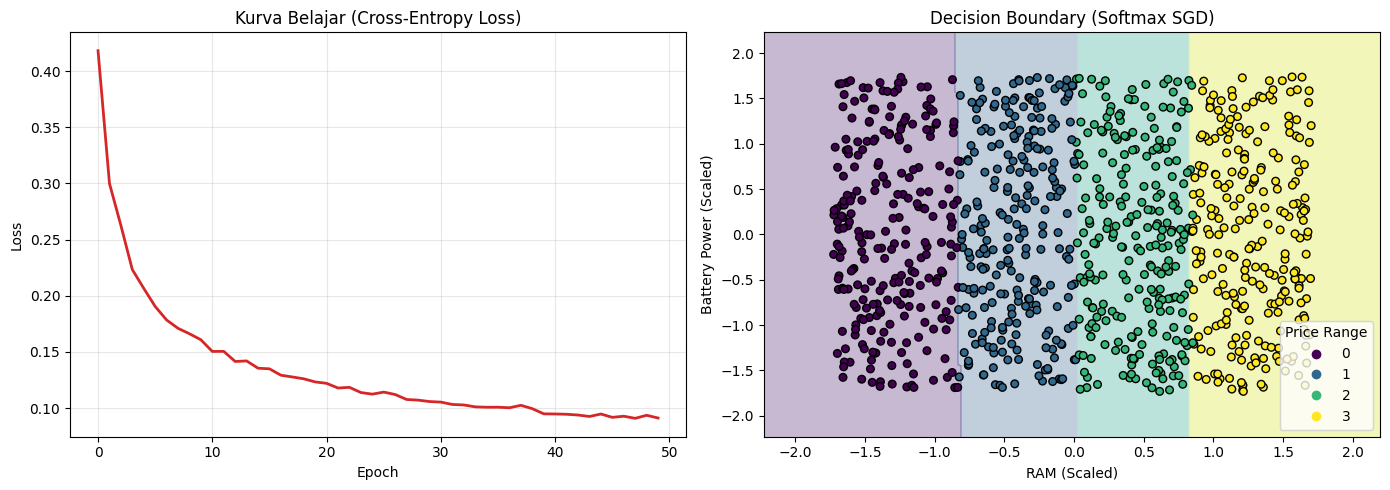

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_name = 'data set harga phone.csv'

try:
    df = pd.read_csv(file_name)
    print(f"Berhasil memuat file: {file_name}")
except FileNotFoundError:
    print(f"Error: File {file_name} tidak ditemukan. Pastikan sudah di-upload ke folder Colab.")

X_raw = df[['ram', 'battery_power']].values

if 'price_range' in df.columns:
    y = df['price_range'].values
    print("Kolom 'price_range' ditemukan sebagai Target.")
else:

    print("Kolom 'price_range' tidak ada. Membuat label simulasi berdasarkan RAM...")
    y = pd.qcut(df['ram'], 4, labels=[0, 1, 2, 3]).astype(int).values

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_scaled = (X_raw - X_mean) / X_std

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_true_oh, y_pred):
    """
    Menghitung seberapa akurat prediksi model.
    y_true_oh: label asli (one-hot)
    y_pred: hasil softmax
    """
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(np.sum(y_true_oh * np.log(y_pred), axis=1))

def to_one_hot(y, num_classes):
    """Mengubah label angka [0,1,2,3] menjadi matriks biner"""
    return np.eye(num_classes)[y]

n_samples, n_features = X_scaled.shape
n_classes = 4
Y_oh = to_one_hot(y, n_classes)

W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros(n_classes)

learning_rate = 0.1
epochs = 50
loss_history = []

print("Memulai Melatih atau Training SGD...")

for epoch in range(epochs):
    indices = np.random.permutation(n_samples)
    X_shuffled = X_scaled[indices]
    Y_shuffled = Y_oh[indices]

    for i in range(n_samples):
        xi = X_shuffled[i:i+1]
        yi = Y_shuffled[i:i+1]

        z = xi @ W + b
        y_pred = softmax(z)

        error = y_pred - yi

        W -= learning_rate * (xi.T @ error)
        b -= learning_rate * np.sum(error, axis=0)

    current_probs = softmax(X_scaled @ W + b)
    loss_history.append(cross_entropy_loss(Y_oh, current_probs))

print("Latihan atau Training Selesai!")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, color='tab:red', linewidth=2)
plt.title('Kurva Belajar (Cross-Entropy Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)

h = 0.02
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = np.argmax(softmax(grid_points @ W + b), axis=1)
grid_preds = grid_preds.reshape(xx.shape)

plt.contourf(xx, yy, grid_preds, alpha=0.3, cmap='viridis')

scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='k', cmap='viridis', s=30)
plt.legend(*scatter.legend_elements(), title="Price Range")
plt.title('Decision Boundary (Softmax SGD)')
plt.xlabel('RAM (Scaled)')
plt.ylabel('Battery Power (Scaled)')

plt.tight_layout()
plt.show()